In [25]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from pathlib import Path
from PIL import Image

print("torch:", torch.__version__)
device = "cuda"
print("device:", device)

def set_seed(seed: int = 42):
    """Make results as reproducible as possible across runs."""
    import os, random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)
    # If you later switch to CUDA and want maximal determinism:
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

set_seed(42)


torch: 2.2.1
device: cuda


In [26]:
# test cell

train_dir_test = Path("ucsc-cse-144-spring-2026-final-project/train")
image_paths_test = sorted(list(train_dir_test.glob("**/*.jpg")))
print({len(image_paths_test)})
print({image_paths_test[0]})
print({image_paths_test[1]})
print({image_paths_test[1078]})
#print({image_paths_test[1079]}) #Couldn't fine the 1079 img?

{1079}
{PosixPath('ucsc-cse-144-spring-2026-final-project/train/0/0.jpg')}
{PosixPath('ucsc-cse-144-spring-2026-final-project/train/0/1.jpg')}
{PosixPath('ucsc-cse-144-spring-2026-final-project/train/99/1078.jpg')}


In [27]:
# test cell 2

train_dir_test_2 = Path("ucsc-cse-144-spring-2026-final-project/train")
image_paths_test_2 = sorted(list(train_dir_test_2.glob("*/*.jpg")))
print({len(image_paths_test_2)})
print({image_paths_test_2[0]})
print({image_paths_test_2[1078]})
# print({image_paths_test_2[1079]})

{1079}
{PosixPath('ucsc-cse-144-spring-2026-final-project/train/0/0.jpg')}
{PosixPath('ucsc-cse-144-spring-2026-final-project/train/99/1078.jpg')}


Total images found: 1079


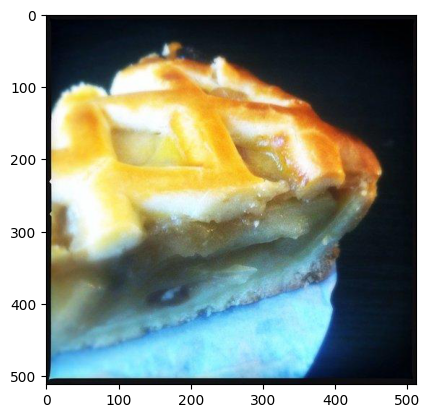

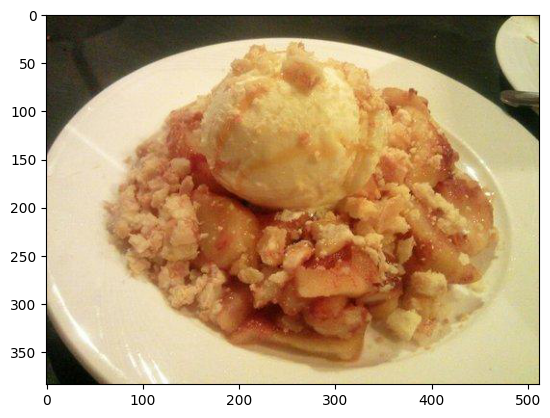

In [28]:
train_dir = Path("ucsc-cse-144-spring-2026-final-project/train")
test_dir = Path("ucsc-cse-144-spring-2026-final-project/test/")

# This looks specifically for: train_dir / any_folder / any_image.jpg
image_paths = sorted(list(train_dir.glob("*/*.jpg")))

print(f"Total images found: {len(image_paths)}")


def open(image_path):
    return Image.open(image_path).convert("RGB")

for image_path in image_paths[:2]:
    image = open(image_path)
    plt.imshow(image)
    plt.show()


# Data Augmentation & Data prep

In [ ]:
# Again the train dir is this:
# train_dir = Path("ucsc-cse-144-spring-2026-final-project/train")

RGB_pre_mean = (0.485, 0.456, 0.406)
RGB_pre_std = (0.229, 0.224, 0.225)

# transform = transforms.Compose([
#     transforms.Resize(256),
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    #transforms.RandomHorizontalFlip(p=0.5),
    #transforms.RandomRotation(15),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(RGB_pre_mean, RGB_pre_std),
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(15), # Should not do for validation
    transforms.ToTensor(),
    transforms.Normalize(RGB_pre_mean, RGB_pre_std),
])

full_train_bad = datasets.ImageFolder(
    root = train_dir,
    transform=train_transforms
)

In [30]:
print(full_train_bad.class_to_idx)

{'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '30': 24, '31': 25, '32': 26, '33': 27, '34': 28, '35': 29, '36': 30, '37': 31, '38': 32, '39': 33, '4': 34, '40': 35, '41': 36, '42': 37, '43': 38, '44': 39, '45': 40, '46': 41, '47': 42, '48': 43, '49': 44, '5': 45, '50': 46, '51': 47, '52': 48, '53': 49, '54': 50, '55': 51, '56': 52, '57': 53, '58': 54, '59': 55, '6': 56, '60': 57, '61': 58, '62': 59, '63': 60, '64': 61, '65': 62, '66': 63, '67': 64, '68': 65, '69': 66, '7': 67, '70': 68, '71': 69, '72': 70, '73': 71, '74': 72, '75': 73, '76': 74, '77': 75, '78': 76, '79': 77, '8': 78, '80': 79, '81': 80, '82': 81, '83': 82, '84': 83, '85': 84, '86': 85, '87': 86, '88': 87, '89': 88, '9': 89, '90': 90, '91': 91, '92': 92, '93': 93, '94': 94, '95': 95, '96': 96, '97': 97, '98': 98, '99': 99}


In [31]:
idx_to_class = {v: k for k, v in full_train_bad.class_to_idx.items()}
target_transform = lambda y: int(idx_to_class[y])

In [32]:
full_train = datasets.ImageFolder(
    root = train_dir,
    transform=train_transforms,
    target_transform=target_transform,
)

for cls in ["10", "2"]:
    raw_idx = full_train.class_to_idx[cls]
    fixed = target_transform(raw_idx)
    print("folder:", cls, "raw_idx:", raw_idx, "fixed_label:", fixed)

folder: 10 raw_idx: 2 fixed_label: 10
folder: 2 raw_idx: 12 fixed_label: 2


In [33]:
print("length of the train set: ", len(full_train))

length of the train set:  1079


In [34]:
val_size = int(len(full_train) * 0.15)
train_size = len(full_train) - val_size
generator = torch.Generator().manual_seed(42)

train_set, val_idx = random_split(full_train, [train_size, val_size], generator=generator)

In [35]:
# train and validation set test, make sure it is randomnized now
labels_train = [train_set[i][1] for i in range(0, train_size)]
labels_val = [val_idx[i][1] for i in range(0, val_size)]
print(set(labels_train))
print(set(labels_val))

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99}
{0, 1, 2, 3, 5, 6, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 24, 25, 26, 28, 29, 31, 32, 33, 35, 36, 37, 38, 40, 41, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 57, 58, 60, 61, 62, 63, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 83, 84, 85, 86, 87, 89, 90, 92, 93, 95, 96, 98}


In [41]:
batch_size = 128
num_workers = 0

# print(val_idx.indices)

full_val = datasets.ImageFolder(
    root=train_dir,
    transform=val_transforms,
    target_transform=target_transform,
)

val_set = torch.utils.data.Subset(full_val, val_idx.indices)

train_loader = DataLoader(train_set, 
                         batch_size=batch_size, 
                         shuffle=True,  
                         num_workers=num_workers)

val_loader = DataLoader(val_set, 
                         batch_size=batch_size, 
                         shuffle=False,  
                         num_workers=num_workers)
# changed this
                         

# Model

In [60]:
# from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# weights = EfficientNet_B0_Weights.DEFAULT
# model = efficientnet_b0(weights=weights)

# from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

# weights = EfficientNet_V2_S_Weights.DEFAULT
# model = efficientnet_v2_s(weights=weights)

# # freeze
# for param in model.features.parameters():
#     param.requires_grad = False

# model.classifier[0] = nn.Dropout(p=0.4, inplace=True)
# in_features = model.classifier[1].in_features
# model.classifier[1] = nn.Linear(in_features, 100)

from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights=weights)

in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, 100)

model = model.to(device)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:00<00:00, 168MB/s]  


Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=100, bias=True)
)


In [61]:
# model = CNNModel().to(device)

criterion = torch.nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001,)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)


# num_epochs = 2
# for epoch in range(num_epochs)x:
#     model.train()
#     train_current_loss = 0
#     train_correct = 0
#     train_total = 0
#     for inputs, labels in train_loader:
#         inputs, labels = inputs.to(device), labels.to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         train_current_loss += loss.item()        
#         _, predicted = torch.max(outputs.data, 1)  # Predicted class
#         train_total += labels.size(0)
#         train_correct += (predicted == labels).sum().item()

#     epoch_loss = train_current_loss / len(train_loader)
#     epoch_accuracy = train_correct / train_total        
#     print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.4f}")


def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy
        


In [62]:
# Q3.2: Validation function
@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model and return (avg_loss, accuracy)."""
    # TODO:
    # - Set model to evaluation mode
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

    # - Loop through batches without computing gradients
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size
    # - Compute loss and accuracy
    # - Return average loss and accuracy
    
    avg_loss = total_loss / total
    accuracy = correct / total
    
    return avg_loss, accuracy
    # ========== YOUR CODE ENDS HERE ============

In [63]:
# Q3.3: Training loop with checkpointing
# Phase 1
epochs = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_epoch = -1
ckpt_path = "./checkpoints/best_mnist_cnn.pt"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

for epoch in range (epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    val_loss, val_acc = evaluate(model, val_loader)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    scheduler.step()

# - Each epoch: train, validate, log metrics
# - Track best validation accuracy and save checkpoint when improved
# - Print training and validation metrics each epoch
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"train loss {train_loss:.4f}, train accuracy {train_acc:.4f}")
    print(f"validation loss {val_loss:.4f}, validation accuracy {val_acc:.4f}")
# - For checkpoint: save a dictionary containing keys `model_state_dict` and `epoch`

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
            },
            ckpt_path,
        )

# ========== YOUR CODE ENDS HERE ============

print("Best val acc:", best_val_acc, "at epoch", best_epoch)
print("Saved to:", ckpt_path)

Epoch 1/10
train loss 4.0783, train accuracy 0.0991
validation loss 2.9894, validation accuracy 0.2547
Epoch 2/10
train loss 2.1890, train accuracy 0.4673
validation loss 2.0883, validation accuracy 0.4099
Epoch 3/10
train loss 1.1511, train accuracy 0.7440
validation loss 1.6435, validation accuracy 0.5590
Epoch 4/10
train loss 0.5944, train accuracy 0.8932
validation loss 1.4942, validation accuracy 0.5652
Epoch 5/10
train loss 0.2822, train accuracy 0.9641
validation loss 1.3277, validation accuracy 0.6025
Epoch 6/10
train loss 0.1594, train accuracy 0.9858
validation loss 1.3846, validation accuracy 0.6149
Epoch 7/10
train loss 0.0960, train accuracy 0.9913
validation loss 1.3184, validation accuracy 0.5839
Epoch 8/10
train loss 0.0563, train accuracy 0.9978
validation loss 1.3033, validation accuracy 0.5963
Epoch 9/10
train loss 0.0463, train accuracy 0.9978
validation loss 1.2792, validation accuracy 0.6149
Epoch 10/10
train loss 0.0389, train accuracy 0.9978
validation loss 1.27

In [ ]:
# phase 2
epoch_2 = 20
i = 0
for param in model.parameters():
    i += 1
    param.requires_grad = True

print("number of params: ", i)

# optimizer_2 = torch.optim.AdamW(
#     model.parameters(), 
#     lr=1e-4, 
#     weight_decay=1e-2
# )
optimizer_2 = torch.optim.AdamW([
    {"params": model.features.parameters(), "lr": 1e-6},
    {"params": model.classifier.parameters(), "lr": 1e-3}
], weight_decay=1e-2)

for epoch in range(epoch_2):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer_2)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    
    val_loss, val_acc = evaluate(model, val_loader)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
                             
    ep = epochs + epoch + 1                              
    print(f"Epoch {ep}/{epochs + epoch_2}")
    print(f"train loss {train_loss:.4f}, train accuracy {train_acc:.4f}")
    print(f"validation loss {val_loss:.4f}, validation accuracy {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc, best_epoch = val_acc, ep - 1
        torch.save({"model_state_dict": model.state_dict(), "epoch": best_epoch}, ckpt_path)
        
print(f"Best val acc: {best_val_acc:.4f}, saved: {ckpt_path}")

number of params:  182


In [ ]:

# val_current_loss = 0
# val_correct = 0
# val_total = 0

   
# model.eval()
# with torch.no_grad():
#     for val_inputs, val_labels in val_loader:
#         val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
#         val_pred = model(val_inputs)
#         val_loss = criterion(val_pred, val_labels)
#         val_current_loss += val_loss.item()
        
#         _, val_predicted = torch.max(val_pred.data, 1)
#         val_total += val_labels.size(0)
#         val_correct += (val_predicted == val_labels).sum().item()
    
#     val_epoch_loss = val_current_loss / len(val_loader)
#     print(f"Val Loss: {val_epoch_loss:.4f}, Val Accuracy: {val_correct / val_total:.4f}")
    

In [ ]:

# model.eval()
# test_current_loss = 0
# test_correct = 0
# test_total = 0
# with torch.no_grad():
#     for inputs, labels in test_loader:
#         # Move data to GPU
#         inputs, labels = inputs.to(device), labels.to(device)
#         # Forward pass
#         outputs = model(inputs)
#         # Compute loss
#         loss = criterion(outputs, labels)

#         test_current_loss += loss.item()
        
#         _, predicted = torch.max(outputs.data, 1)  # Predicted class
#         test_total += labels.size(0)
#         test_correct += (predicted == labels).sum().item()
    
#     epoch_loss = test_current_loss / len(test_loader)
#     epoch_accuracy = test_correct / test_total
#     print(f"Test Loss: {epoch_loss:.4f}, Test Accuracy: {epoch_accuracy:.4f}")
   

30


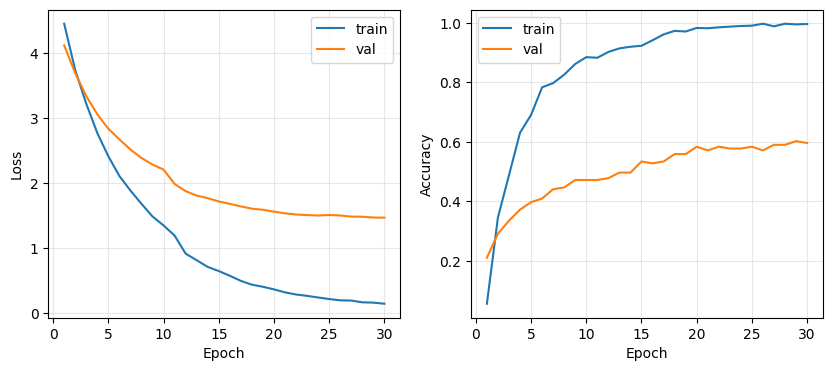

In [ ]:
# Plotting
epoch_total = epochs + epoch_2


print(epoch_total)

epochs_range = range(1, epoch_total+1)

# print(len(epochs_range))
# print(len(history["train_loss"]))

# history["train_loss"].
# print((history["train_loss"]))

      
# epochs_range = range(1, 12)


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="train")
plt.plot(epochs_range, history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="train")
plt.plot(epochs_range, history["val_acc"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

In [ ]:
# Make predictions, convert to csv

# import pandas as pd

# checkpoint = torch.load(ckpt_path, map_location=device)
# model.load_state_dict(checkpoint["model_state_dict"])

# model.eval()

# train_dir_test = Path("ucsc-cse-144-spring-2026-final-project/train")

# sample_path = Path("ucsc-cse-144-spring-2026-final-project/sample_submission.csv")
# test_dir = Path("ucsc-cse-144-spring-2026-final-project/test")
# sub = pd.read_csv(sample_path)
# preds = []

# for img_id in sub["ID"]:
#     img_path = test_dir / img_id
#     img = Image.open(img_path).convert("RGB")
#     x = val_transforms(img).unsqueeze(0).to(device)
#     with torch.no_grad():
#         preds.append(model(x).argmax(1).item())

# sub["Label"] = preds
# sub.to_csv("ucsc-cse-144-spring-2026-final-project/submission.csv", index=False)
# print("saved submission.csv")

saved submission.csv


In [48]:
# Make predictions, convert to csv
import pandas as pd

checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_dir = Path("ucsc-cse-144-spring-2026-final-project/test")
ids, preds = [], []

for img_path in sorted(test_dir.glob("*.jpg"), key=lambda p: int(p.stem)):
    img = Image.open(img_path).convert("RGB")
    x = val_transforms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x).argmax(1).item()
    ids.append(img_path.name)
    preds.append(pred)

submission = pd.DataFrame({"ID": ids, "Label": preds})
out_path = Path("ucsc-cse-144-spring-2026-final-project/submission.csv")

submission.to_csv(out_path, index=False)
print("rows:", len(submission))
print(submission.head())
print(submission.tail())

ModuleNotFoundError: No module named 'pandas'